_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Neural Data Science Project — Visual Coding

## Working with calcium-imaging data

In this project you will receive a data set and you will be asked to **formulate your own
research question** to investigate. Use the methods that you have learned throughout this
course to explore the data and to answer your question. You are free to use tools,
resources and libraries as you see fit. Use comments and markdown cells to document your
thought process and to explain your reasoning. We encourage you to compare different
algorithms or to implement state-of-the-art solutions. The notebook should be
self-contained, although you may offload some functions to a `utils.py`.

In [ ]:
# import packages here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import jupyter_black

jupyter_black.load()

%load_ext autoreload
%autoreload 2
from utils import *

## Context

The data set was recorded with *in vivo* 2-photon calcium imaging of genetically
identified neurons in the **visual cortex of mice** (Allen Brain Observatory, *Visual
Coding 2P*; GCaMP6 indicator). Head-fixed mice passively viewed a battery of visual
stimuli while running freely on a disc, and the fluorescence of each neuron was recorded
as a proxy for its activity.

The **same population of cells** was imaged across **three sessions** (`A`, `B`, `C`),
each presenting different stimuli. Cells have been **matched across sessions**, so cell
`i` refers to the same neuron in every session (`data["matched_cell_ids"]`).

For each session the data contains:
- `t` — time vector (s)
- `dff` — preprocessed activity traces (ΔF/F), shape `(n_cells, n_timepoints)`
- `roi_masks` — binary ROI mask per cell
- `max_projection` — maximum-intensity projection of the field of view
- `running_speed` — running speed over time (a secondary, behavioural variable)
- `stim_epoch_table` — which stimulus block ran when
- `stim_tables` — one table per stimulus present in that session (timing + parameters)

The curated **stimulus modalities** across the three sessions are:

| Stimulus | Session | Parameters |
|---|---|---|
| `drifting_gratings`    | A | `orientation`, `temporal_frequency`, `blank_sweep` |
| `static_gratings`      | B | `orientation`, `spatial_frequency`, `phase` |
| `natural_scenes`       | B | `frame` (index into the image template) |
| `locally_sparse_noise` | C | `frame` (index into the noise template) |

For `natural_scenes` and `locally_sparse_noise` the actual stimulus images are provided in
`data["templates"]`. You do **not** have to use all of the data — pick what your research
question needs. Each session's traces also contain segments of other stimuli (see
`stim_epoch_table`); you can ignore those segments or incorporate them.

In [ ]:
# load the data

data = load_data()
print_info(data)

matched cells: 47
templates: ['locally_sparse_noise', 'natural_scenes'] --- (9000, 16, 28), (118, 918, 1174)

session A (three_session_A)
  t: (115471,), dff: (47, 115471), roi_masks: (47, 512, 512)
  stim 'drifting_gratings': (628, 5) cols=['temporal_frequency', 'orientation', 'blank_sweep', 'start', 'end']

session B (three_session_B)
  t: (113850,), dff: (47, 113850), roi_masks: (47, 512, 512)
  stim 'natural_scenes': (5950, 3) cols=['frame', 'start', 'end']
  stim 'static_gratings': (6000, 5) cols=['orientation', 'spatial_frequency', 'phase', 'start', 'end']

session C (three_session_C)
  t: (105738,), dff: (47, 105738), roi_masks: (47, 512, 512)
  stim 'locally_sparse_noise': (8880, 3) cols=['frame', 'start', 'end']


## A quick tour of the data

In [ ]:
list(data["sessions"]["A"])

['stim_tables',
 'session_type',
 't',
 'dff',
 'roi_masks',
 'max_projection',
 'running_speed',
 'stim_epoch_table']

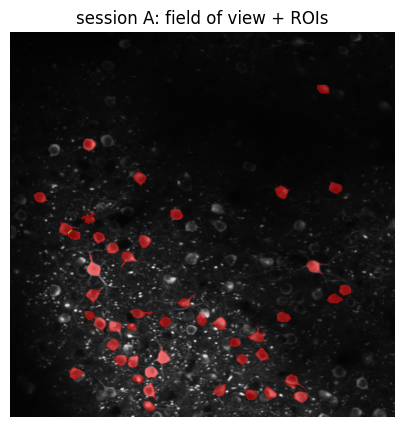

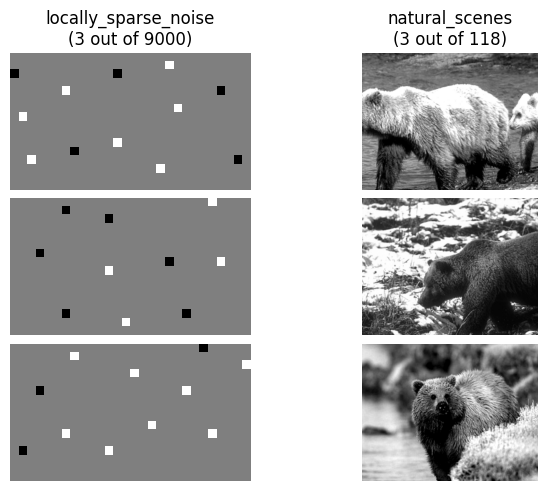

In [ ]:
plotter = Plotter(data)
plotter.field_of_view("A")
plotter.stimulus_examples(3)
plt.show()

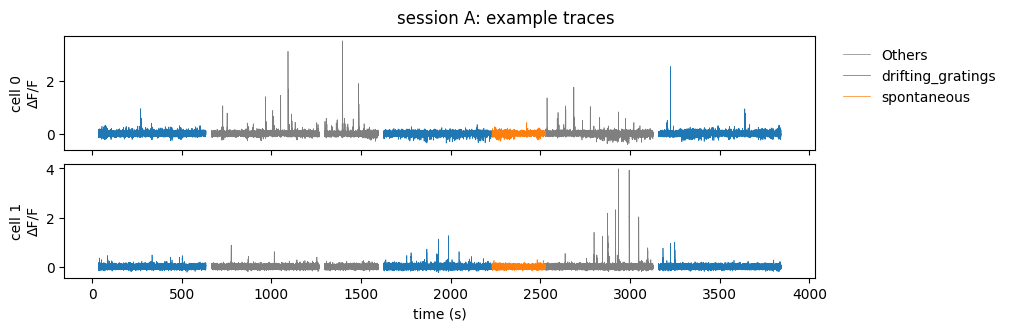

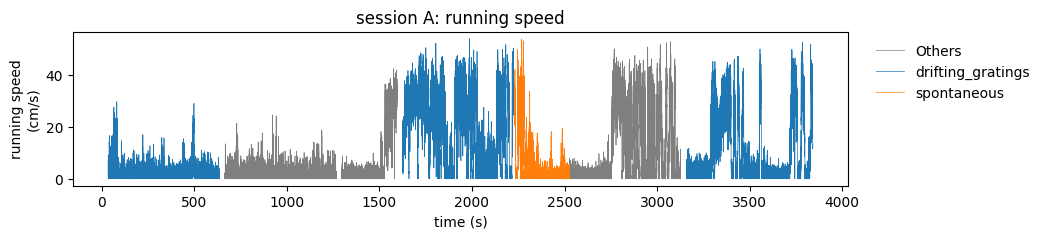

In [ ]:
plotter.traces("A", cells=(0, 1), conditions=["drifting_gratings", "spontaneous"])
ax = plotter.running_speed("A", conditions=["drifting_gratings", "spontaneous"])
# ax.set_xlim(100, 400)
# ax.axhline(0.5, color="red")
# ax.axhline(3, color="red")
# ax.set_ylim(-0.1, 20)
plt.show()

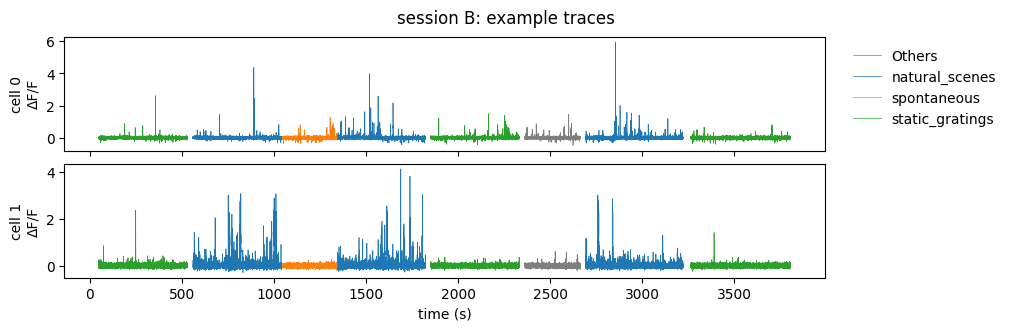

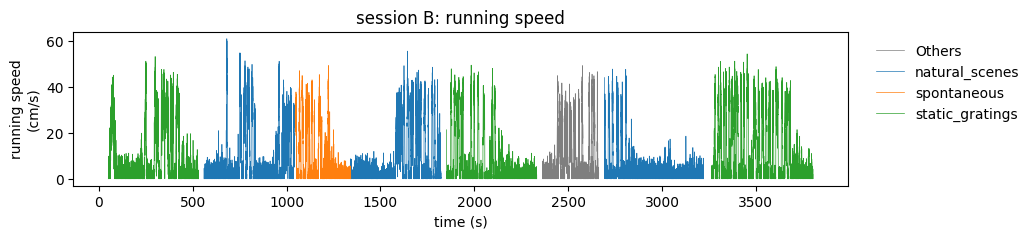

In [ ]:
plotter.traces(
    "B",
    cells=(0, 1),
    conditions=["static_gratings", "natural_scenes", "spontaneous"],
)

ax = plotter.running_speed(
    "B", conditions=["static_gratings", "natural_scenes", "spontaneous"]
)
plt.show()

In [ ]:
# plotter.traces(
#     "C",
#     cells=(0, 1),
#     conditions=["locally_sparse_noise", "spontaneous"],
# )

# ax = plotter.running_speed("C", conditions=["locally_sparse_noise", "spontaneous"])
# plt.show()

The length of trials 
> `natrual_scenes`: each picture is shown randomly by 50 times in total.

In [ ]:
test_df = data["sessions"]["A"]["stim_tables"]["drifting_gratings"]
print(np.unique(test_df["end"] - test_df["start"], return_counts=True))

test_df = data["sessions"]["B"]["stim_tables"]["natural_scenes"]
print(np.unique(test_df["end"] - test_df["start"], return_counts=True))

test_df = data["sessions"]["B"]["stim_tables"]["static_gratings"]
print(np.unique(test_df["end"] - test_df["start"], return_counts=True))
# data["sessions"]["B"]["stim_epoch_table"]

(array([59., 60., 61.]), array([194, 431,   3]))
(array([ 7,  8, 15]), array([5811,  138,    1]))
(array([7., 8., 9.]), array([5867,  132,    1]))


---

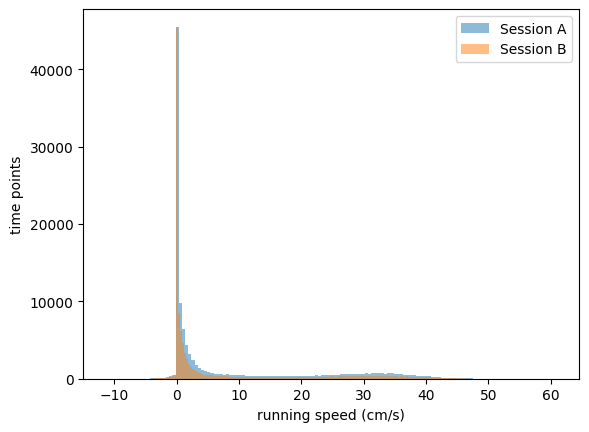

In [ ]:
plt.hist(
    data["sessions"]["A"]["running_speed"][0], bins="auto", label="Session A", alpha=0.5
)
plt.hist(
    data["sessions"]["B"]["running_speed"][0], bins="auto", label="Session B", alpha=0.5
)
plt.xlim(-15)
plt.xlabel("running speed (cm/s)")
plt.ylabel("time points")
plt.legend()

## Question

> It has been shown that Layer 2/3 and 4 neurons in mice V1 are positively modulated by local motion during the visual responsiveness task, specifically in drifting grating. Through the Allen dataset, we want to verify whether those modulations are present in the same grating task and how different they are under naturalistic stimuli.
<!-- 
Implement all steps of the processing pipeline necessary to answer your research question.
Depending on the direction you choose, think about:

1. **Pre-processing** (resampling, filtering, spike inference)
2. **Feature extraction** — e.g. tuning curves (drifting / static gratings), spatial
   receptive fields (locally sparse noise), or responses to natural scenes
3. **Model fitting** — tuning functions, linear/encoding models, etc.
4. **Statistical testing** — significance of selectivity / responses, cross-validation

Some directions you could take (you are not limited to these):
- direction / orientation / spatial- / temporal-frequency tuning
- ON/OFF receptive-field structure and size
- how reliably cells respond to natural scenes, or whether scene identity can be decoded
- comparing the *same* matched neuron across stimuli (e.g. does grating tuning predict
  natural-scene selectivity?)
- whether running speed modulates visual responses -->

---

## Preprocessing

In [ ]:
# extract the trial data
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
list(trial_data_dict)

['drifting_gratings', 'static_gratings', 'natural_scenes', 'spontaneous']